In [65]:
import pandas as pd
training_data = pd.read_csv('training_data/cleaned_training_data.csv')
training_data.head()

,PULocationID,month,Year,num_stations,unemployment_rate,log_total_revenue,lag_1,lag_1_fhv,Borough_Brooklyn,Borough_EWR,Borough_Manhattan,Borough_Queens,Borough_Staten Island
0,1,2,2023,0,4.25,0.000000,0.000000,4.582311,0.0,1.0,0.0,0.0,0.0
1,1,4,2023,0,4.25,2.580217,1.290108,3.943371,0.0,1.0,0.0,0.0,0.0
2,1,5,2023,0,4.25,9.360064,1.529511,3.492703,0.0,1.0,0.0,0.0,0.0
3,1,6,2023,0,4.25,0.000000,4.771532,4.044279,0.0,1.0,0.0,0.0,0.0
4,1,7,2023,0,4.25,5.314437,2.657218,4.191778,0.0,1.0,0.0,0.0,0.0


In [66]:
import statsmodels.api as sm

# Prepare data
target = "log_total_revenue"
X = training_data.drop(columns=[target])
y = training_data[target]

# Clean
model_data = pd.concat([y, X], axis=1)
model_data = model_data.replace([float("inf"), float("-inf")], pd.NA).dropna()
y = model_data[target]
X = model_data.drop(columns=[target])

# Add constant
X = sm.add_constant(X)

# Train/test split by year (all zones)
X_train = X[X['Year'] < 2026]
X_test = X[X['Year'] >= 2026]
y_train = y.loc[X_train.index]
y_test = y.loc[X_test.index]

# Drop PULocationID ONLY FOR TRAINING
X_train_model = X_train.drop('PULocationID', axis=1)
model = sm.OLS(y_train, X_train_model).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:      log_total_revenue   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.869
Method:                 Least Squares   F-statistic:                     7557.
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:09:18   Log-Likelihood:                -64355.
No. Observations:               12570   AIC:                         1.287e+05
Df Residuals:                   12558   BIC:                         1.288e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  1232.58

In [67]:
zones_vals = training_data['PULocationID'].unique()
for ZONE in zones_vals:
    X_test_zone = X_test[X_test['PULocationID'] == ZONE]  # Filter first (has PULocationID)
    X_test_zone_model = X_test_zone.drop('PULocationID', axis=1)  # Drop for model
    y_test_zone = y_test.loc[X_test_zone.index]

    # Predict
    y_pred_zone = model.predict(X_test_zone_model)

    # Metrics
    mae = abs(y_test_zone - y_pred_zone).mean()
    print(f"MAE for Zone {ZONE}: {mae:.4f}")
    from sklearn.metrics import r2_score
    r2 = r2_score(y_test_zone, y_pred_zone)
    print(f"R² for Zone {ZONE}: {r2:.4f}")

MAE for Zone 1: 54.6275
R² for Zone 1: -468.9366
MAE for Zone 2: 20.4913
R² for Zone 2: -11.2296
MAE for Zone 3: 23.5868
R² for Zone 3: 0.8133
MAE for Zone 4: 20.8299
R² for Zone 4: -3.9266
MAE for Zone 5: 8.2354
R² for Zone 5: -7.7230
MAE for Zone 6: 46.2352
R² for Zone 6: -1.3313
MAE for Zone 7: 28.2708
R² for Zone 7: -4.9719
MAE for Zone 8: 16.5711
R² for Zone 8: 0.4409
MAE for Zone 9: 37.7540
R² for Zone 9: 0.4392
MAE for Zone 10: 28.4788
R² for Zone 10: -6.1407
MAE for Zone 11: 47.4801
R² for Zone 11: 0.4441
MAE for Zone 12: 60.0436
R² for Zone 12: -0.1067
MAE for Zone 13: 21.3706
R² for Zone 13: -2.0502
MAE for Zone 14: 24.7973
R² for Zone 14: -5.0071
MAE for Zone 15: 58.5581
R² for Zone 15: -0.2017
MAE for Zone 16: 56.4488
R² for Zone 16: 0.1907
MAE for Zone 17: 25.7531
R² for Zone 17: -5.1482
MAE for Zone 18: 37.2590
R² for Zone 18: 0.4995
MAE for Zone 19: 66.1998
R² for Zone 19: 0.0103
MAE for Zone 20: 29.0653
R² for Zone 20: 0.7727
MAE for Zone 21: 38.0891
R² for Zone 21: 0.4

In [68]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Train Random Forest on all data
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42)
rf.fit(X_train.drop('PULocationID', axis=1), y_train)

# Evaluate on each zone
for ZONE in zones_vals:
    X_test_zone = X_test[X_test['PULocationID'] == ZONE]
    X_test_zone_model = X_test_zone.drop('PULocationID', axis=1)
    y_test_zone = y_test.loc[X_test_zone.index]
    
    # Predict with Random Forest
    y_pred_zone = rf.predict(X_test_zone_model)
    
    # Metrics
    mae = mean_absolute_error(y_test_zone, y_pred_zone)
    r2 = r2_score(y_test_zone, y_pred_zone)
    
    print(f"Zone {ZONE}: MAE={mae:.4f}, R²={r2:.4f}")

Zone 1: MAE=4.8549, R²=-2.8808
Zone 2: MAE=3.2852, R²=0.5208
Zone 3: MAE=3.5027, R²=0.9968
Zone 4: MAE=7.0358, R²=0.5770
Zone 5: MAE=0.9357, R²=0.6985
Zone 6: MAE=8.9860, R²=0.8466
Zone 7: MAE=3.6571, R²=0.8662
Zone 8: MAE=2.6722, R²=0.9696
Zone 9: MAE=3.8117, R²=0.9898
Zone 10: MAE=8.6471, R²=0.1082
Zone 11: MAE=0.9211, R²=0.9997
Zone 12: MAE=3.3055, R²=0.9973
Zone 13: MAE=4.9884, R²=0.8192
Zone 14: MAE=2.6685, R²=0.9306
Zone 15: MAE=2.7852, R²=0.9927
Zone 16: MAE=2.8048, R²=0.9952
Zone 17: MAE=3.3811, R²=0.8928
Zone 18: MAE=2.4352, R²=0.9986
Zone 19: MAE=1.9492, R²=0.9984
Zone 20: MAE=1.7198, R²=0.9991
Zone 21: MAE=1.5267, R²=0.9994
Zone 22: MAE=2.1240, R²=0.9985
Zone 23: MAE=3.3544, R²=0.6402
Zone 24: MAE=11.2763, R²=-1.6559
Zone 25: MAE=36.1073, R²=-0.0213
Zone 26: MAE=1.4332, R²=0.9991
Zone 27: MAE=3.7728, R²=0.6939
Zone 28: MAE=2.7463, R²=0.9977
Zone 29: MAE=2.5019, R²=0.9142
Zone 30: MAE=2.1758, R²=0.8460
Zone 31: MAE=5.7062, R²=0.9413
Zone 32: MAE=1.7491, R²=0.9530
Zone 33: MAE

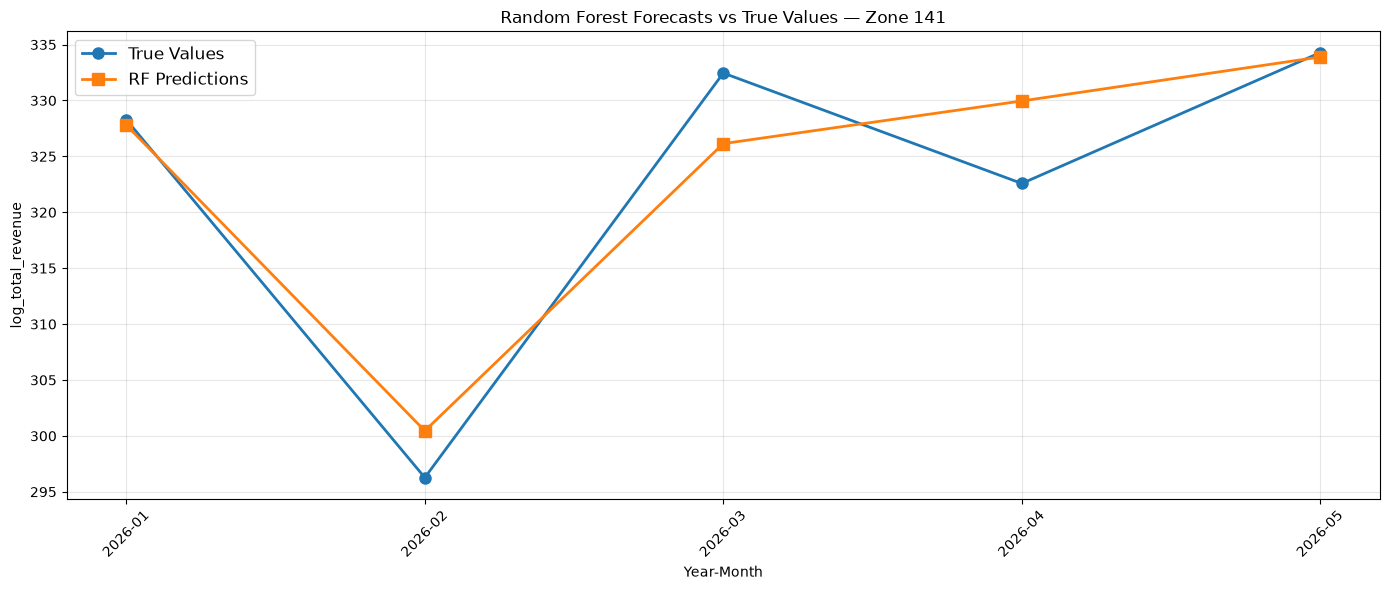

In [69]:
# Zone 137 test data
ZONE = 141
X_test_zone = X_test[X_test['PULocationID'] == ZONE].drop('PULocationID', axis=1)
y_test_zone = y_test.loc[X_test_zone.index]

# Predictions from Random Forest
y_pred_zone = rf.predict(X_test_zone)

# Create time labels
time_labels = (
    X_test[X_test['PULocationID'] == ZONE]['Year'].astype(str)
    + "-"
    + X_test[X_test['PULocationID'] == ZONE]['month'].astype(str).str.zfill(2)
)

# Plot
plt.figure(figsize=(14, 6))
plt.plot(time_labels.values, y_test_zone.values, label='True Values', linewidth=2, marker='o', markersize=8)
plt.plot(time_labels.values, y_pred_zone, label='RF Predictions', linewidth=2, marker='s', markersize=8)
plt.xlabel('Year-Month')
plt.ylabel('log_total_revenue')
plt.title(f'Random Forest Forecasts vs True Values — Zone {ZONE}')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

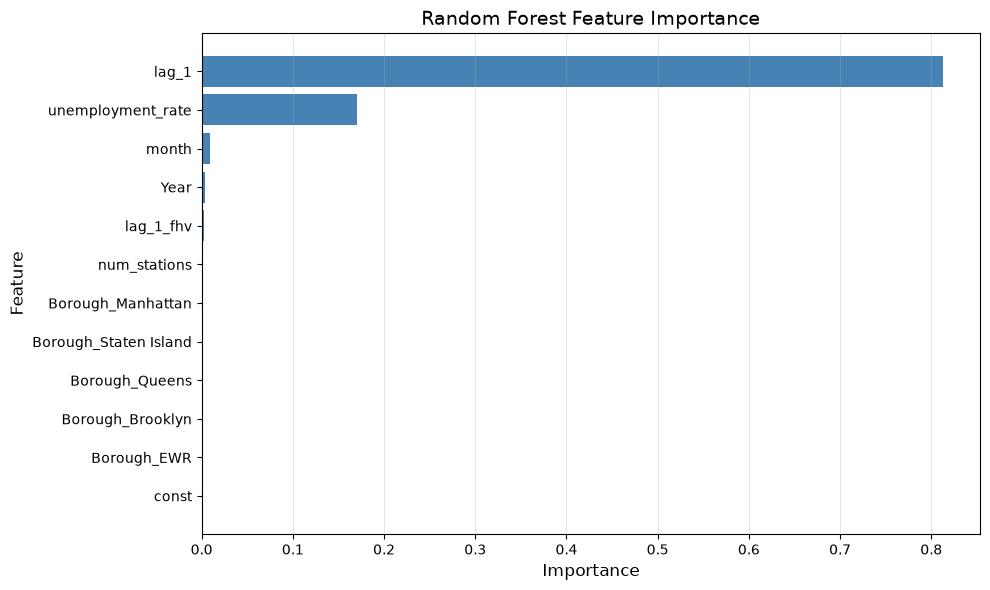

Top 10 Features by Importance:
              Feature  Importance
                lag_1    0.812779
    unemployment_rate    0.170097
                month    0.009222
                 Year    0.004021
            lag_1_fhv    0.003131
         num_stations    0.000201
    Borough_Manhattan    0.000161
Borough_Staten Island    0.000160
       Borough_Queens    0.000150
     Borough_Brooklyn    0.000076


In [70]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.drop('PULocationID', axis=1).columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Random Forest Feature Importance', fontsize=14)
plt.gca().invert_yaxis()  # Highest importance at top
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Print top features
print("Top 10 Features by Importance:")
print(feature_importance.head(10).to_string(index=False))